In [46]:
# Importing libraries

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Analysis
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from sklearn.metrics.pairwise import cosine_similarity

# Warning
import warnings
warnings.filterwarnings("ignore")

In [48]:
Data = pd.read_csv("superstoredata.csv")
Data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


In [3]:
Data.describe()

,Quantity,UnitPrice,CustomerID,Sales
count,541909.000000,541909.000000,406829.000000,541909.000000
mean,9.552250,4.611114,15287.690570,17.987795
std,218.081158,96.759853,1713.600303,378.810824
min,-80995.000000,-11062.060000,12346.000000,-168469.600000
25%,1.000000,1.250000,13953.000000,3.400000
50%,3.000000,2.080000,15152.000000,9.750000
75%,10.000000,4.130000,16791.000000,17.400000
max,80995.000000,38970.000000,18287.000000,168469.600000


In [4]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
 8   Sales        541909 non-null  float64
dtypes: float64(3), int64(1), object(5)
memory usage: 37.2+ MB


In [5]:
Data.shape

(541909, 9)

In [6]:
Data.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
Sales               0
dtype: int64

In [7]:
unique_data = Data.nunique()
print(unique_data)

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
Sales           5998
dtype: int64


In [8]:
data = Data.copy()
data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"])

In [9]:
data['Description'] = data['Description'].fillna('Unknown Item')

In [10]:
data.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
Sales               0
dtype: int64

In [11]:
data_clean = data.dropna()

In [12]:
data_clean.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Sales          0
dtype: int64

In [13]:
# Identify rows with negative values in the 'Quantity' column
negative_quantity_index = data_clean[data_clean['Quantity'] < 0].index

# Remove rows with negative values in the 'Quantity' column
Data_cleaned = data_clean.drop(index=negative_quantity_index)

In [14]:
# Remove rows with zero values in the 'UnitPrice' column
Data_cleaned = Data_cleaned[Data_cleaned['UnitPrice'] != 0]

In [15]:
Data_cleaned.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [16]:
Data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
 8   Sales        397884 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.4+ MB


In [17]:
num_var = ['Quantity', 'UnitPrice', 'CustomerID', 'Sales']
cat_var = ['Country']

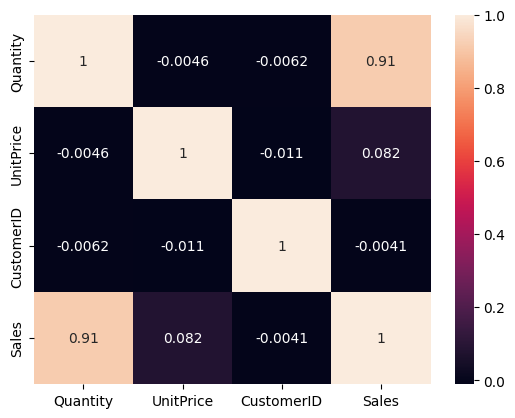

In [18]:
corr_matrix = Data_cleaned[num_var].corr()
sns.heatmap(corr_matrix, annot=True)
plt.show()

In [19]:
for column in cat_var:
    print("\n", column)
    print(Data_cleaned[column].value_counts())


 Country
Country
United Kingdom          354321
Germany                   9040
France                    8341
EIRE                      7236
Spain                     2484
Netherlands               2359
Belgium                   2031
Switzerland               1841
Portugal                  1462
Australia                 1182
Norway                    1071
Italy                      758
Channel Islands            748
Finland                    685
Cyprus                     614
Sweden                     451
Austria                    398
Denmark                    380
Poland                     330
Japan                      321
Israel                     248
Unspecified                244
Singapore                  222
Iceland                    182
USA                        179
Canada                     151
Greece                     145
Malta                      112
United Arab Emirates        68
European Community          60
RSA                         57
Lebanon              

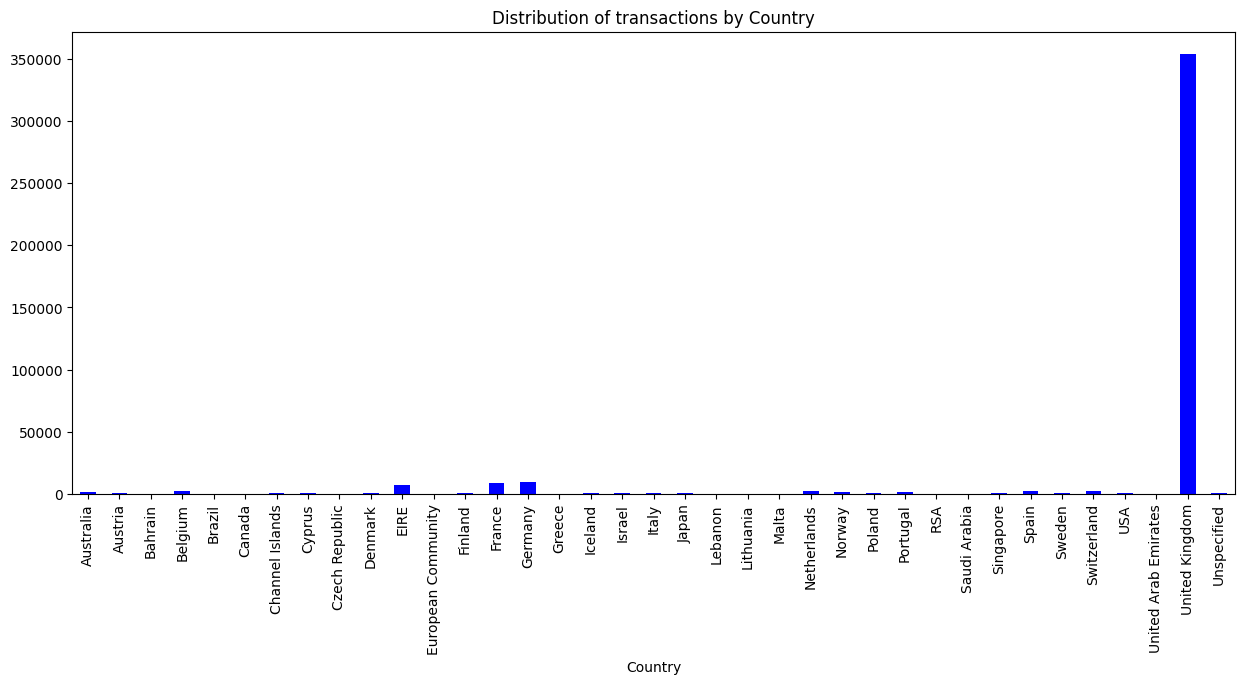

In [20]:
import matplotlib.pyplot as plt

# Assuming your data is stored in a variable named data

# Group the data by 'Country' and calculate the count of invoices for each country
country_counts = Data_cleaned.groupby('Country')['StockCode'].count()

# Plot a pie chart
plt.figure(figsize=(15, 6))
country_counts.plot(kind='bar', color='blue' )
plt.title('Distribution of transactions by Country')
plt.ylabel('')
plt.show()

In [21]:
monthly_sales_table = Data_cleaned.resample('M', on='InvoiceDate')['Sales'].sum().reset_index()

monthly_sales_table = pd.DataFrame(monthly_sales_table)
monthly_sales_table['Year'] = monthly_sales_table['InvoiceDate'].dt.year
monthly_sales_table['Month'] = monthly_sales_table['InvoiceDate'].dt.month_name()
monthly_sales_table['Cumulative Sum'] = monthly_sales_table['Sales'].cumsum().round(2)
monthly_sales_table['Sales'] = monthly_sales_table['Sales'].round(2)

monthly_sales_table = monthly_sales_table[['InvoiceDate', 'Year', 'Month', 'Sales', 'Cumulative Sum']]
monthly_sales_table

,InvoiceDate,Year,Month,Sales,Cumulative Sum
0,2010-12-31,2010,December,572713.89,572713.89
1,2011-01-31,2011,January,569445.04,1142158.93
2,2011-02-28,2011,February,447137.35,1589296.28
3,2011-03-31,2011,March,595500.76,2184797.04
4,2011-04-30,2011,April,469200.36,2653997.40
5,2011-05-31,2011,May,678594.56,3332591.96
6,2011-06-30,2011,June,661213.69,3993805.65
7,2011-07-31,2011,July,600091.01,4593896.66
8,2011-08-31,2011,August,645343.90,5239240.56
9,2011-09-30,2011,September,952838.38,6192078.94


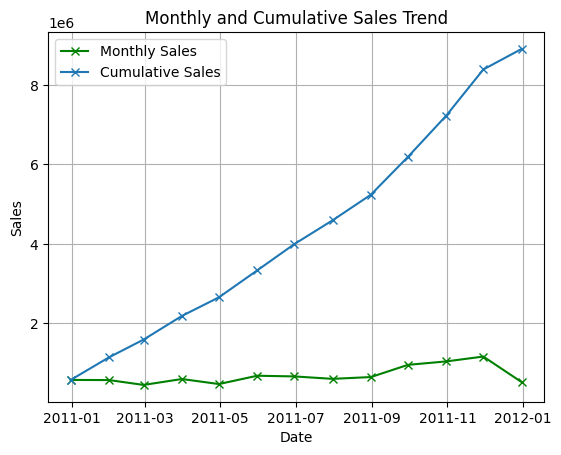

In [22]:
# Plot monthly sales
plt.plot(monthly_sales_table['InvoiceDate'], monthly_sales_table['Sales'], label='Monthly Sales', marker = 'x', color = 'green')

# Plot cumulative sales
plt.plot(monthly_sales_table['InvoiceDate'], monthly_sales_table['Cumulative Sum'], label='Cumulative Sales', marker = 'x')

# Add labels and title
plt.title('Monthly and Cumulative Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
#Identifying top products by frequency, volume and sales
# Frequency
top_products_fq = Data_cleaned['Description'].value_counts().head(10)

# Volume
top_products_vl = Data_cleaned.groupby('Description')['Quantity'].sum().sort_values(ascending = False).head(10)

# Sales
top_products_sa = Data_cleaned.groupby('Description')['Sales'].sum().sort_values(ascending = False).head(10)

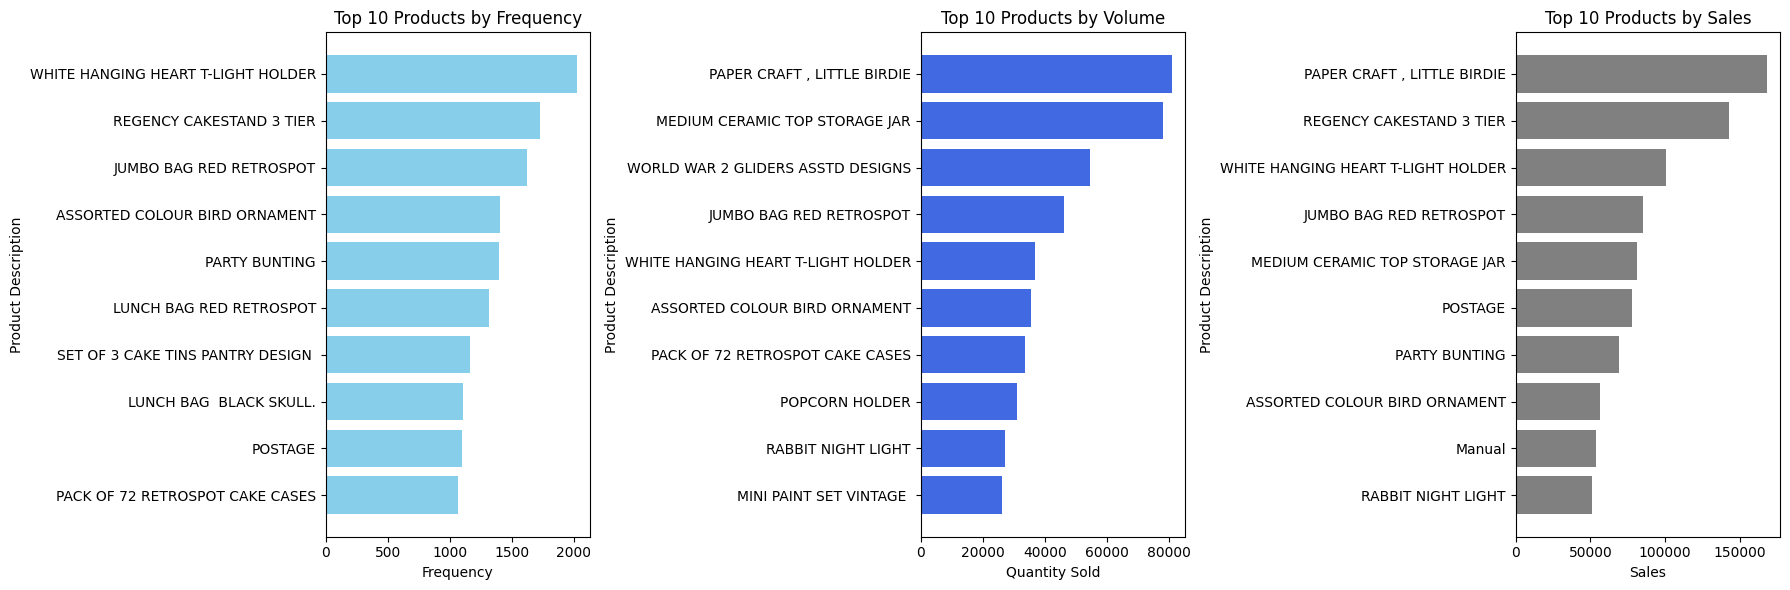

In [24]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot frequency of top products
axs[0].barh(top_products_fq.index[::-1], top_products_fq.values[::-1], color='skyblue')
axs[0].set_title('Top 10 Products by Frequency')
axs[0].set_xlabel('Frequency')
axs[0].set_ylabel('Product Description')

# Plot volume (quantity sold) of top products
axs[1].barh(top_products_vl.index[::-1], top_products_vl.values[::-1], color='royalblue')
axs[1].set_title('Top 10 Products by Volume')
axs[1].set_xlabel('Quantity Sold')
axs[1].set_ylabel('Product Description')

# Plot sales of top products
axs[2].barh(top_products_sa.index[::-1], top_products_sa.values[::-1], color='grey')
axs[2].set_title('Top 10 Products by Sales')
axs[2].set_xlabel('Sales')
axs[2].set_ylabel('Product Description')

plt.tight_layout()
plt.show()

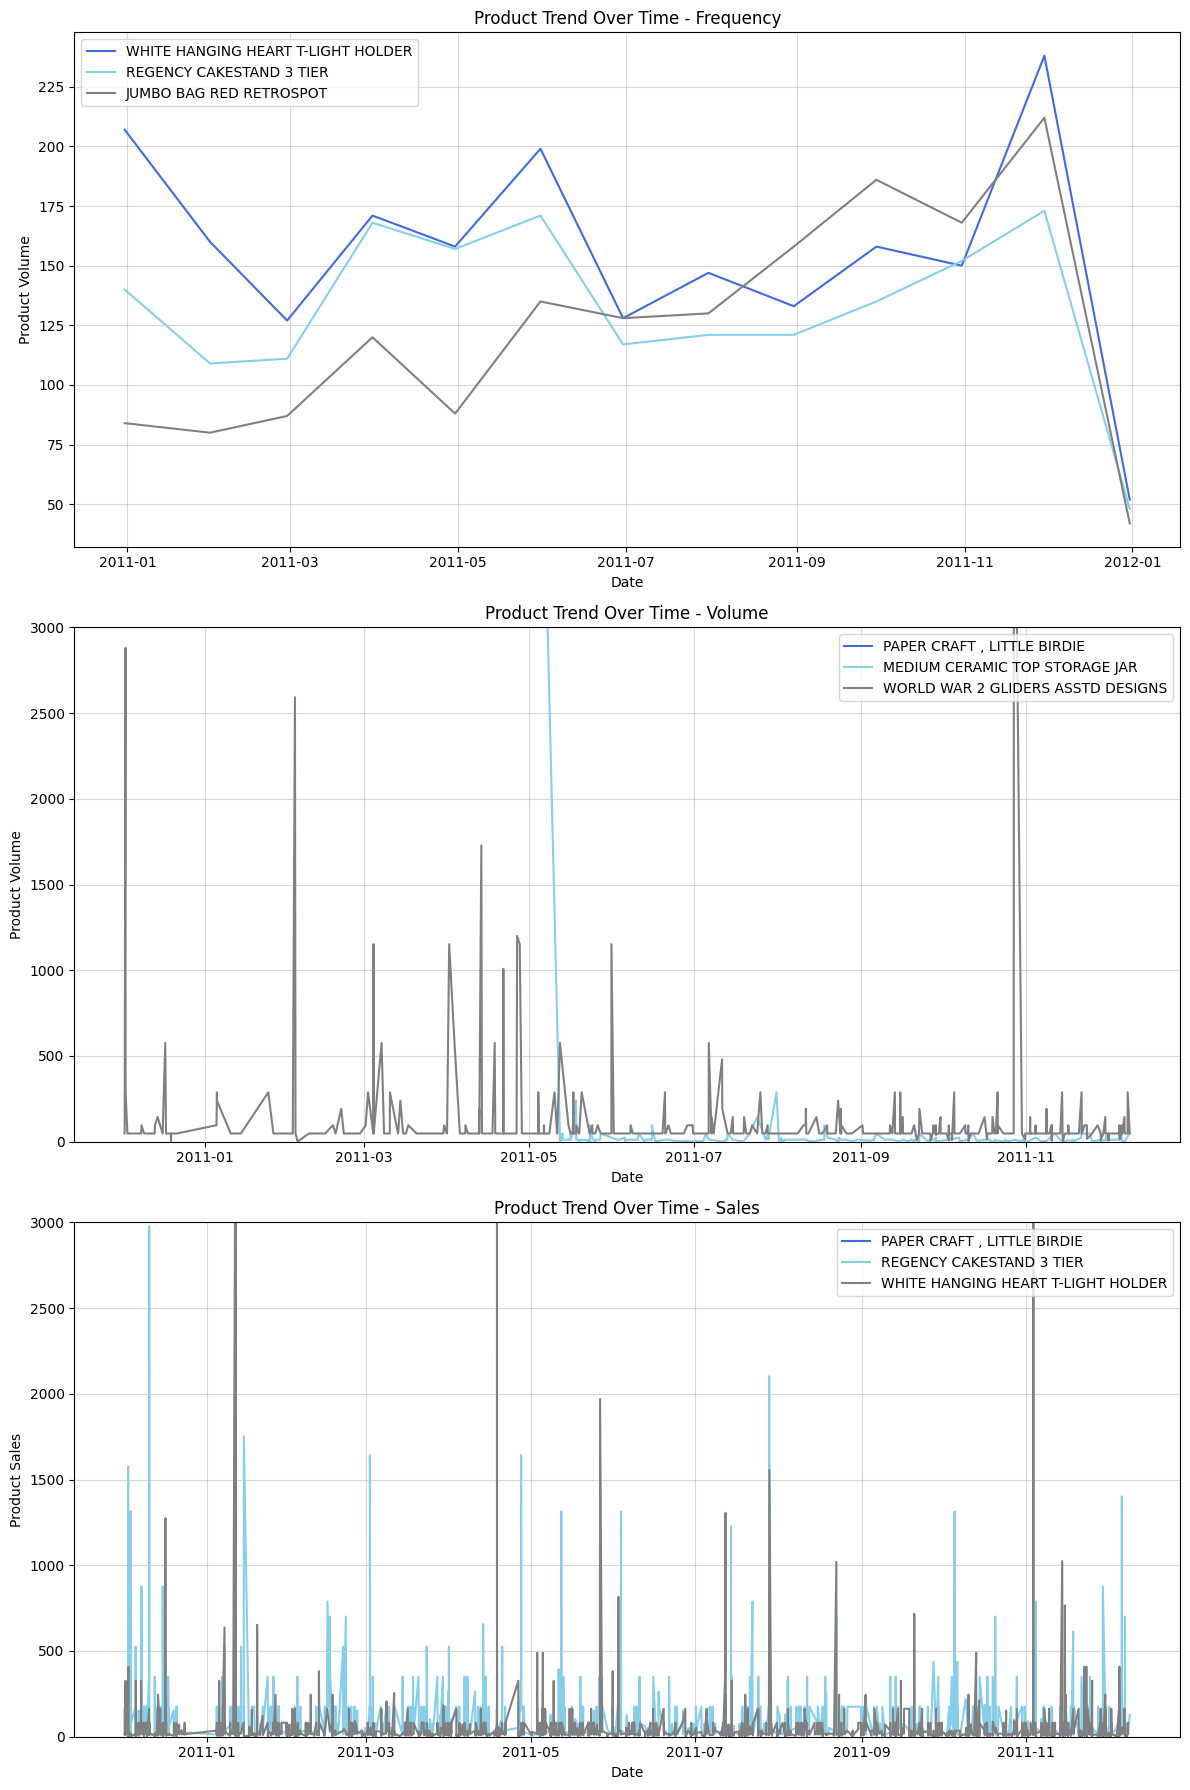

In [25]:
# Top 3 Frequency
top3_fq = top_products_fq.head(3).index.to_list()
Data_cleaned_top3_fq = Data_cleaned[Data_cleaned['Description'].isin(top3_fq)]
monthly_fq = Data_cleaned_top3_fq.resample('M', on='InvoiceDate')['Description'].value_counts().reset_index()

# Top 3 Volume
top3_vl = top_products_vl.head(3).index.to_list()
Data_cleaned_top3_vl = Data_cleaned[Data_cleaned['Description'].isin(top3_vl)]

# Top 3 Sales
top3_sa = top_products_sa.head(3).index.to_list()
Data_cleaned_top3_sa = Data_cleaned[Data_cleaned['Description'].isin(top3_sa)]

fig, axs = plt.subplots(3, 1, figsize=(12, 18))

# Plot for Top 3 Frequency
for item, color in zip(top3_fq, ['royalblue', 'skyblue', 'grey']):
    plot_data_fq = monthly_fq[monthly_fq['Description']==item]
    axs[0].plot(plot_data_fq['InvoiceDate'], plot_data_fq['count'], label=item, color=color)
axs[0].set_title('Product Trend Over Time - Frequency')
axs[0].set_xlabel('Date')
axs[0].set_ylabel('Product Volume')
axs[0].legend()
axs[0].grid(alpha=0.5)

# Plot for Top 3 Volume
for item, color in zip(top3_vl, ['royalblue', 'skyblue', 'grey']):
    plot_data_vl = Data_cleaned_top3_vl[Data_cleaned_top3_vl['Description']==item]
    axs[1].plot(plot_data_vl['InvoiceDate'], plot_data_vl['Quantity'], label=item, color=color)
axs[1].set_title('Product Trend Over Time - Volume')
axs[1].set_xlabel('Date')
axs[1].set_ylabel('Product Volume')
axs[1].legend()
axs[1].grid(alpha=0.5)
axs[1].set_ylim(0, 3000)

# Plot for Top 3 Sales
for item, color in zip(top3_sa, ['royalblue', 'skyblue', 'grey']):
    plot_data_sa = Data_cleaned_top3_sa[Data_cleaned_top3_sa['Description']==item]
    axs[2].plot(plot_data_sa['InvoiceDate'], plot_data_sa['Sales'], label=item, color=color)
axs[2].set_title('Product Trend Over Time - Sales')
axs[2].set_xlabel('Date')
axs[2].set_ylabel('Product Sales')
axs[2].legend()
axs[2].grid(alpha=0.5)
axs[2].set_ylim(0, 3000)

plt.tight_layout()
plt.show()

In [26]:
!pip install datasketch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.3/88.3 kB 2.7 MB/s eta 0:00:00


In [27]:
from datasketch import MinHashLSHForest, MinHash

# Feature selection and engineering
features = Data_cleaned[['Quantity', 'UnitPrice', 'CustomerID','Sales']]

# LSH model training
lsh_forest = MinHashLSHForest(num_perm=128)

# Convert features to MinHash objects
minhashes = []
for _, row in features.iterrows():
    minhash = MinHash(num_perm=128)
    minhash.update(str(row['Quantity']).encode('utf-8'))
    minhash.update(str(row['UnitPrice']).encode('utf-8'))
    minhash.update(str(row['CustomerID']).encode('utf-8'))
    minhash.update(str(row['Sales']).encode('utf-8'))
    minhashes.append(minhash)

# Add MinHash objects to LSH Forest
for i, minhash in enumerate(minhashes):
    lsh_forest.add(str(i), minhash)

# Index the LSH Forest
lsh_forest.index()

# Nearest neighbor search and clustering
similar_customers = {}
for i, minhash in enumerate(minhashes):
    similar = lsh_forest.query(minhash, 5)  # Find 5 nearest neighbors
    similar_customers[str(i)] = similar

# Output similar customers
for customer, similar in similar_customers.items():
    print(f"Customer {customer} has similar customers: {similar}")

Streaming output truncated to the last 5000 lines.
Customer 29511 has similar customers: ['174327', '593', '29511', '9638', '276586']
Customer 29512 has similar customers: ['29512', '147700', '100209', '148648', '135178']
Customer 29513 has similar customers: ['22099', '29513', '21837', '29515', '29514']
Customer 29514 has similar customers: ['22099', '29513', '21837', '29515', '29514']
Customer 29515 has similar customers: ['22099', '29513', '21837', '29515', '29514']
Customer 29516 has similar customers: ['165928', '29616', '81129', '29516', '29572']
Customer 29517 has similar customers: ['29601', '29517', '340923', '122258', '304383']
Customer 29518 has similar customers: ['29518', '29559', '29538', '29560', '29539']
Customer 29519 has similar customers: ['29521', '29519', '29529', '29520', '29522']
Customer 29520 has similar customers: ['29521', '29519', '29529', '29520', '29522']
Customer 29521 has similar customers: ['29521', '29519', '29529', '29520', '29522']
Customer 29522 has

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



Streaming output truncated to the last 5000 lines.
Customer 150935 has similar customers: ['68010', '94436', '150896', '150935', '226108']
Customer 150936 has similar customers: ['18569', '111088', '150936', '111089', '150922']
Customer 150937 has similar customers: ['150881', '210256', '150937', '18675', '150887']
Customer 150938 has similar customers: ['154709', '19911', '253928', '150938', '52839']
Customer 150939 has similar customers: ['150950', '150889', '150939', '150862', '210031']
Customer 150940 has similar customers: ['355481', '150861', '355480', '150940', '150920']
Customer 150941 has similar customers: ['54374', '54372', '18582', '150941', '54373']
Customer 150942 has similar customers: ['322403', '322404', '322375', '355519', '150942']
Customer 150943 has similar customers: ['150869', '18572', '150943', '109540', '150926']
Customer 150944 has similar customers: ['346956', '150944', '279432', '18570', '279431']
Customer 150945 has similar customers: ['259469', '82037', '1

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



Streaming output truncated to the last 5000 lines.
Customer 211100 has similar customers: ['246910', '155030', '155035', '211100', '155032']
Customer 211101 has similar customers: ['117072', '211101', '117041', '117071', '246876']
Customer 211102 has similar customers: ['211105', '2331', '122', '211102', '1595']
Customer 211103 has similar customers: ['20187', '211103', '7834', '20188', '155063']
Customer 211104 has similar customers: ['155054', '211104', '211107', '155056', '117076']
Customer 211105 has similar customers: ['211105', '2331', '122', '211102', '1595']
Customer 211106 has similar customers: ['52099', '329885', '211106', '279465', '308524']
Customer 211107 has similar customers: ['155054', '211104', '211107', '155056', '117076']
Customer 211108 has similar customers: ['117051', '211073', '117041', '211108', '211074']
Customer 211109 has similar customers: ['155034', '200911', '254714', '211109', '254694']
Customer 211110 has similar customers: ['357166', '155044', '211110'

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



Streaming output truncated to the last 5000 lines.
Customer 328309 has similar customers: ['193298', '339472', '9689', '25124', '328309']
Customer 328310 has similar customers: ['60940', '285978', '182640', '105176', '328310']
Customer 328311 has similar customers: ['328311', '256408', '395458', '283144', '183092']
Customer 328312 has similar customers: ['328312', '177308', '326507', '319485', '123066']
Customer 328313 has similar customers: ['19538', '100058', '328313', '288620', '359759']
Customer 328314 has similar customers: ['236119', '328314', '100284', '100276', '100285']
Customer 328315 has similar customers: ['92060', '209003', '328315', '236130', '209002']
Customer 328316 has similar customers: ['283552', '236114', '328302', '236110', '328316']
Customer 328317 has similar customers: ['262116', '142396', '328317', '315811', '198396']
Customer 328318 has similar customers: ['208805', '156749', '122369', '151638', '223951']
Customer 328319 has similar customers: ['131724', '9941

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



Streaming output truncated to the last 5000 lines.
Customer 392884 has similar customers: ['272255', '331941', '392884', '158805', '189926']
Customer 392885 has similar customers: ['297579', '198241', '272256', '207603', '392885']
Customer 392886 has similar customers: ['203224', '392886', '47580', '306045', '9752']
Customer 392887 has similar customers: ['392887', '188647', '194597', '380097', '116256']
Customer 392888 has similar customers: ['203218', '366030', '392888', '5197', '158836']
Customer 392889 has similar customers: ['392889', '20566', '250099', '62199', '62201']
Customer 392890 has similar customers: ['27339', '104279', '79540', '27341', '20585']
Customer 392891 has similar customers: ['158825', '62204', '218', '203220', '189929']
Customer 392892 has similar customers: ['27347', '9740', '27346', '47574', '47568']
Customer 392893 has similar customers: ['27347', '9740', '27346', '47574', '47568']
Customer 392894 has similar customers: ['27352', '47570', '9735', '9736', '27

In [28]:
# Apriori Algorithm to see the association rules between items,
# but it didn't help in our analysis.Hence we will ignore it.
# Prepare transaction data
transaction_data = Data_cleaned.groupby('InvoiceNo')['Description'].apply(list).reset_index(name='Items')
# Convert transactions
transaction_encoded = transaction_data['Items'].str.join('|').str.get_dummies()
frequent_itemsets = apriori(transaction_encoded, min_support=0.05, use_colnames=True)
frequent_itemsets.head()
# Generate association rules
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=0.5)
filtered_rules = rules[(rules['lift'] >= 0.1) & (rules['confidence'] >= 0.1)]
sorted_rules = filtered_rules.sort_values(by='lift', ascending=False)
print(sorted_rules.head())

Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, lift, leverage, conviction, zhangs_metric]
Index: []


we will explore a recommendation system based on item-item collaborative filtering using the provided dataset. The goal is to recommend similar items to a given item based on user interactions, such as purchases or quantity of items bought.

In [29]:
data_rec = Data_cleaned[['CustomerID', 'StockCode', 'Quantity']]
data_rec.head()

,CustomerID,StockCode,Quantity
0,17850.0,85123A,6
1,17850.0,71053,6
2,17850.0,84406B,8
3,17850.0,84029G,6
4,17850.0,84029E,6


In [30]:
interactions_matrix = Data_cleaned.pivot_table(index='CustomerID', columns='StockCode', values='Quantity', fill_value=0)
interactions_matrix

StockCode,10002,10080,10120,10123C,10124A,10124G,10125,10133,10135,11001,...,90214V,90214W,90214Y,90214Z,BANK CHARGES,C2,DOT,M,PADS,POST
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346.0,0.0,0,0,0,0,0,0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0.0,0,0.00
12347.0,0.0,0,0,0,0,0,0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0.0,0,0.00
12348.0,0.0,0,0,0,0,0,0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0.0,0,2.25
12349.0,0.0,0,0,0,0,0,0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0.0,0,1.00
12350.0,0.0,0,0,0,0,0,0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0.0,0,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18280.0,0.0,0,0,0,0,0,0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0.0,0,0.00
18281.0,0.0,0,0,0,0,0,0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0.0,0,0.00
18282.0,0.0,0,0,0,0,0,0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0.0,0,0.00


In [31]:
item_similarity_matrix = cosine_similarity(interactions_matrix.T)
item_similarity_matrix

array([[1.00000000e+00, 0.00000000e+00, 3.71241456e-03, ...,
        1.60077061e-03, 0.00000000e+00, 1.15161871e-01],
       [0.00000000e+00, 1.00000000e+00, 0.00000000e+00, ...,
        5.79933280e-05, 0.00000000e+00, 0.00000000e+00],
       [3.71241456e-03, 0.00000000e+00, 1.00000000e+00, ...,
        1.92035461e-02, 0.00000000e+00, 1.07859907e-03],
       ...,
       [1.60077061e-03, 5.79933280e-05, 1.92035461e-02, ...,
        1.00000000e+00, 0.00000000e+00, 2.02012280e-03],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 1.00000000e+00, 0.00000000e+00],
       [1.15161871e-01, 0.00000000e+00, 1.07859907e-03, ...,
        2.02012280e-03, 0.00000000e+00, 1.00000000e+00]])

In [32]:
def recommend_items(item_id, item_similarity_matrix, top_n=5):
    item_index = interactions_matrix.columns.get_loc(item_id)
    item_similarity_scores = item_similarity_matrix[item_index]
    similar_items_indices = item_similarity_scores.argsort()[::-1]
    similar_items_indices = similar_items_indices[similar_items_indices != item_index]
    return similar_items_indices[:top_n]

In [35]:
item_id = '85123A'
top_similar_items = recommend_items(item_id, item_similarity_matrix)
print("Top similar items to item", item_id, ":", top_similar_items)

Top similar items to item 85123A : [ 397 2590  355 2621  753]


In [36]:
item_popularity = Data_cleaned.groupby('StockCode').size().sort_values(ascending=False)
item_popularity

StockCode
85123A    2035
22423     1723
85099B    1618
84879     1408
47566     1396
          ... 
84854        1
23664        1
90152B       1
90152C       1
35004P       1
Length: 3665, dtype: int64

In [44]:
def recommend_items_for_new_user(item_similarity_matrix, item_popularity, interactions_matrix, top_n):
    # Get the top N popular items
    top_popular_items = item_popularity.head(top_n).index

    recommendations = []
    for item_id in top_popular_items:
        item_index = interactions_matrix.columns.get_loc(item_id)
        item_similarity_scores = item_similarity_matrix[item_index]
        similar_items_indices = item_similarity_scores.argsort()[::-1]
        similar_items_indices = similar_items_indices[similar_items_indices != item_index]
        recommendations.extend(interactions_matrix.columns[similar_items_indices[:top_n]])

    # Get unique recommendations and limit to top N
    unique_recommendations = list(pd.unique(recommendations))[:top_n]

    return unique_recommendations

In [45]:
top_n = 10
recommendations = recommend_items_for_new_user(item_similarity_matrix, item_popularity, interactions_matrix, top_n)
print("Recommendations for new user:", recommendations)

Recommendations for new user: ['21175', '47556B', '21108', '48185', '21733', '21485', '22507', '21770', '22637', '21873']
